In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
multivariate_univariate_path = kagglehub.dataset_download('rupakroy/lstm-datasets-multivariate-univariate')
print(f"Dataset downloaded to {multivariate_univariate_path}")
print('Data source import complete.')


Using Colab cache for faster access to the 'lstm-datasets-multivariate-univariate' dataset.
Dataset downloaded to /kaggle/input/lstm-datasets-multivariate-univariate
Data source import complete.


In [3]:
import numpy as np
import pandas as pd
train_data=pd.read_csv(multivariate_univariate_path + "/LSTM-Multivariate_pollution.csv")
test_data=pd.read_csv(multivariate_univariate_path +  "/pollution_test_data1.csv")

In [4]:
import os
os.environ["TF_GPU_ALLOCATOR"]="cuda_malloc_async"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]="1.00"

In [5]:
#Viewing the first few entries of the data
train_data.head()

,date,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
0,2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
1,2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2,2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
3,2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
4,2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0


In [6]:
train_data.tail()

,date,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
43795,2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,NW,231.97,0,0
43796,2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,NW,237.78,0,0
43797,2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,NW,242.70,0,0
43798,2014-12-31 22:00:00,8.0,-22,-4.0,1034.0,NW,246.72,0,0
43799,2014-12-31 23:00:00,12.0,-21,-3.0,1034.0,NW,249.85,0,0


In [7]:
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
pollution,43800.0,94.013516,92.252276,0.00,24.00,68.00,132.25,994.0
dew,43800.0,1.828516,14.429326,-40.00,-10.00,2.00,15.00,28.0
temp,43800.0,12.459041,12.193384,-19.00,2.00,14.00,23.00,42.0
press,43800.0,1016.447306,10.271411,991.00,1008.00,1016.00,1025.00,1046.0
wnd_spd,43800.0,23.894307,50.022729,0.45,1.79,5.37,21.91,585.6
snow,43800.0,0.052763,0.760582,0.00,0.00,0.00,0.00,27.0
rain,43800.0,0.195023,1.416247,0.00,0.00,0.00,0.00,36.0


In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43800 entries, 0 to 43799
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       43800 non-null  object 
 1   pollution  43800 non-null  float64
 2   dew        43800 non-null  int64  
 3   temp       43800 non-null  float64
 4   press      43800 non-null  float64
 5   wnd_dir    43800 non-null  object 
 6   wnd_spd    43800 non-null  float64
 7   snow       43800 non-null  int64  
 8   rain       43800 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 3.0+ MB


In [9]:
train_data.isnull().sum()

,0
date,0
pollution,0
dew,0
temp,0
press,0
wnd_dir,0
wnd_spd,0
snow,0
rain,0


In [10]:
train_data=train_data.drop(columns=['date'])

In [11]:
train_data.isna().sum()

,0
pollution,0
dew,0
temp,0
press,0
wnd_dir,0
wnd_spd,0
snow,0
rain,0


In [12]:
train_data["wnd_dir"].value_counts()

,count
wnd_dir,
SE,15290
NW,14130
cv,9384
NE,4996


In [13]:
test_data.head()

,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution
0,-16,4,1027,SE,3.58,0,0,128
1,-17,5,1027,SE,7.60,0,0,77
2,-16,4,1027,SE,9.39,0,0,65
3,-16,1,1028,cv,0.89,0,0,79
4,-14,0,1028,NE,1.79,0,0,93


In [14]:
test_data.tail()

,dew,temp,press,wnd_dir,wnd_spd,snow,rain,pollution
341,-23,-2,1034,NW,231.97,0,0,8
342,-22,-3,1034,NW,237.78,0,0,10
343,-22,-3,1034,NW,242.70,0,0,10
344,-22,-4,1034,NW,246.72,0,0,8
345,-21,-3,1034,NW,249.85,0,0,12


In [15]:
test_data.describe().T

,count,mean,std,min,25%,50%,75%,max
dew,346.0,-13.878613,4.029925,-27.00,-16.00,-14.000,-11.0000,-6.00
temp,346.0,-0.653179,4.548732,-9.00,-4.00,-1.500,2.0000,11.00
press,346.0,1026.083815,5.996272,1011.00,1022.00,1027.000,1031.0000,1035.00
wnd_spd,346.0,62.473815,107.500012,0.45,2.67,7.825,58.7825,441.18
snow,346.0,0.000000,0.000000,0.00,0.00,0.000,0.0000,0.00
rain,346.0,0.000000,0.000000,0.00,0.00,0.000,0.0000,0.00
pollution,346.0,96.398844,98.298524,0.00,14.00,63.500,157.5000,444.00


In [16]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346 entries, 0 to 345
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   dew        346 non-null    int64  
 1   temp       346 non-null    int64  
 2   press      346 non-null    int64  
 3   wnd_dir    346 non-null    object 
 4   wnd_spd    346 non-null    float64
 5   snow       346 non-null    int64  
 6   rain       346 non-null    int64  
 7   pollution  346 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 21.8+ KB


In [17]:
test_data.isnull().sum()

,0
dew,0
temp,0
press,0
wnd_dir,0
wnd_spd,0
snow,0
rain,0
pollution,0


In [18]:
test_data.isna().sum()

,0
dew,0
temp,0
press,0
wnd_dir,0
wnd_spd,0
snow,0
rain,0
pollution,0


In [19]:
test_data["wnd_dir"].value_counts()

,count
wnd_dir,
NW,206
cv,72
SE,34
NE,34


In [20]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
train_data['wnd_dir']=label_encoder.fit_transform(train_data['wnd_dir'])
test_data['wnd_dir']=label_encoder.transform(test_data['wnd_dir'])

In [21]:
features=['dew','temp','press','wnd_dir','wnd_spd','snow','rain']
target='pollution'

In [22]:
X=train_data[features].values
y=train_data[target].values.reshape(-1,1)
X_test=test_data[features].values
y_test=test_data[target].values.reshape(-1,1)

In [23]:
from sklearn.preprocessing import MinMaxScaler
X_scaler=MinMaxScaler()
y_scaler=MinMaxScaler()

X_scaled=X_scaler.fit_transform(X)
y_scaled=y_scaler.fit_transform(y)

X_test_scaled=X_scaler.transform(X_test)
y_test_scaled=y_scaler.transform(y_test)

In [24]:
def create_sequences(X,y,time_steps):
    Xs,ys=[],[]
    for i in range(time_steps,len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y[i])
    return np.array(Xs),np.array(ys)

In [25]:
time_steps=24
X_seq,y_seq=create_sequences(X_scaled,y_scaled,time_steps)
X_test_seq,y_test_seq=create_sequences(X_test_scaled,y_test_scaled,time_steps)

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val=train_test_split(X_seq,y_seq,test_size=0.1,random_state=42,shuffle=False)

In [27]:
from tensorflow.keras import layers, models

model=models.Sequential([
    layers.Bidirectional(layers.LSTM(units=256,activation='tanh',return_sequences=True),input_shape=(time_steps,X_train.shape[2])),
    layers.Dropout(rate=0.3),
    layers.Bidirectional(layers.LSTM(units=128,activation='tanh',return_sequences=True)),
    layers.Dropout(rate=0.3),
    layers.Bidirectional(layers.LSTM(units=64,activation='tanh')),
    layers.Dropout(rate=0.3),
    layers.Dense(units=64,activation='relu'),
    layers.Dense(units=1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 512)        │       540,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 24, 256)        │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,369,729 (5.23 MB)

 Trainable params: 1,369,729 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

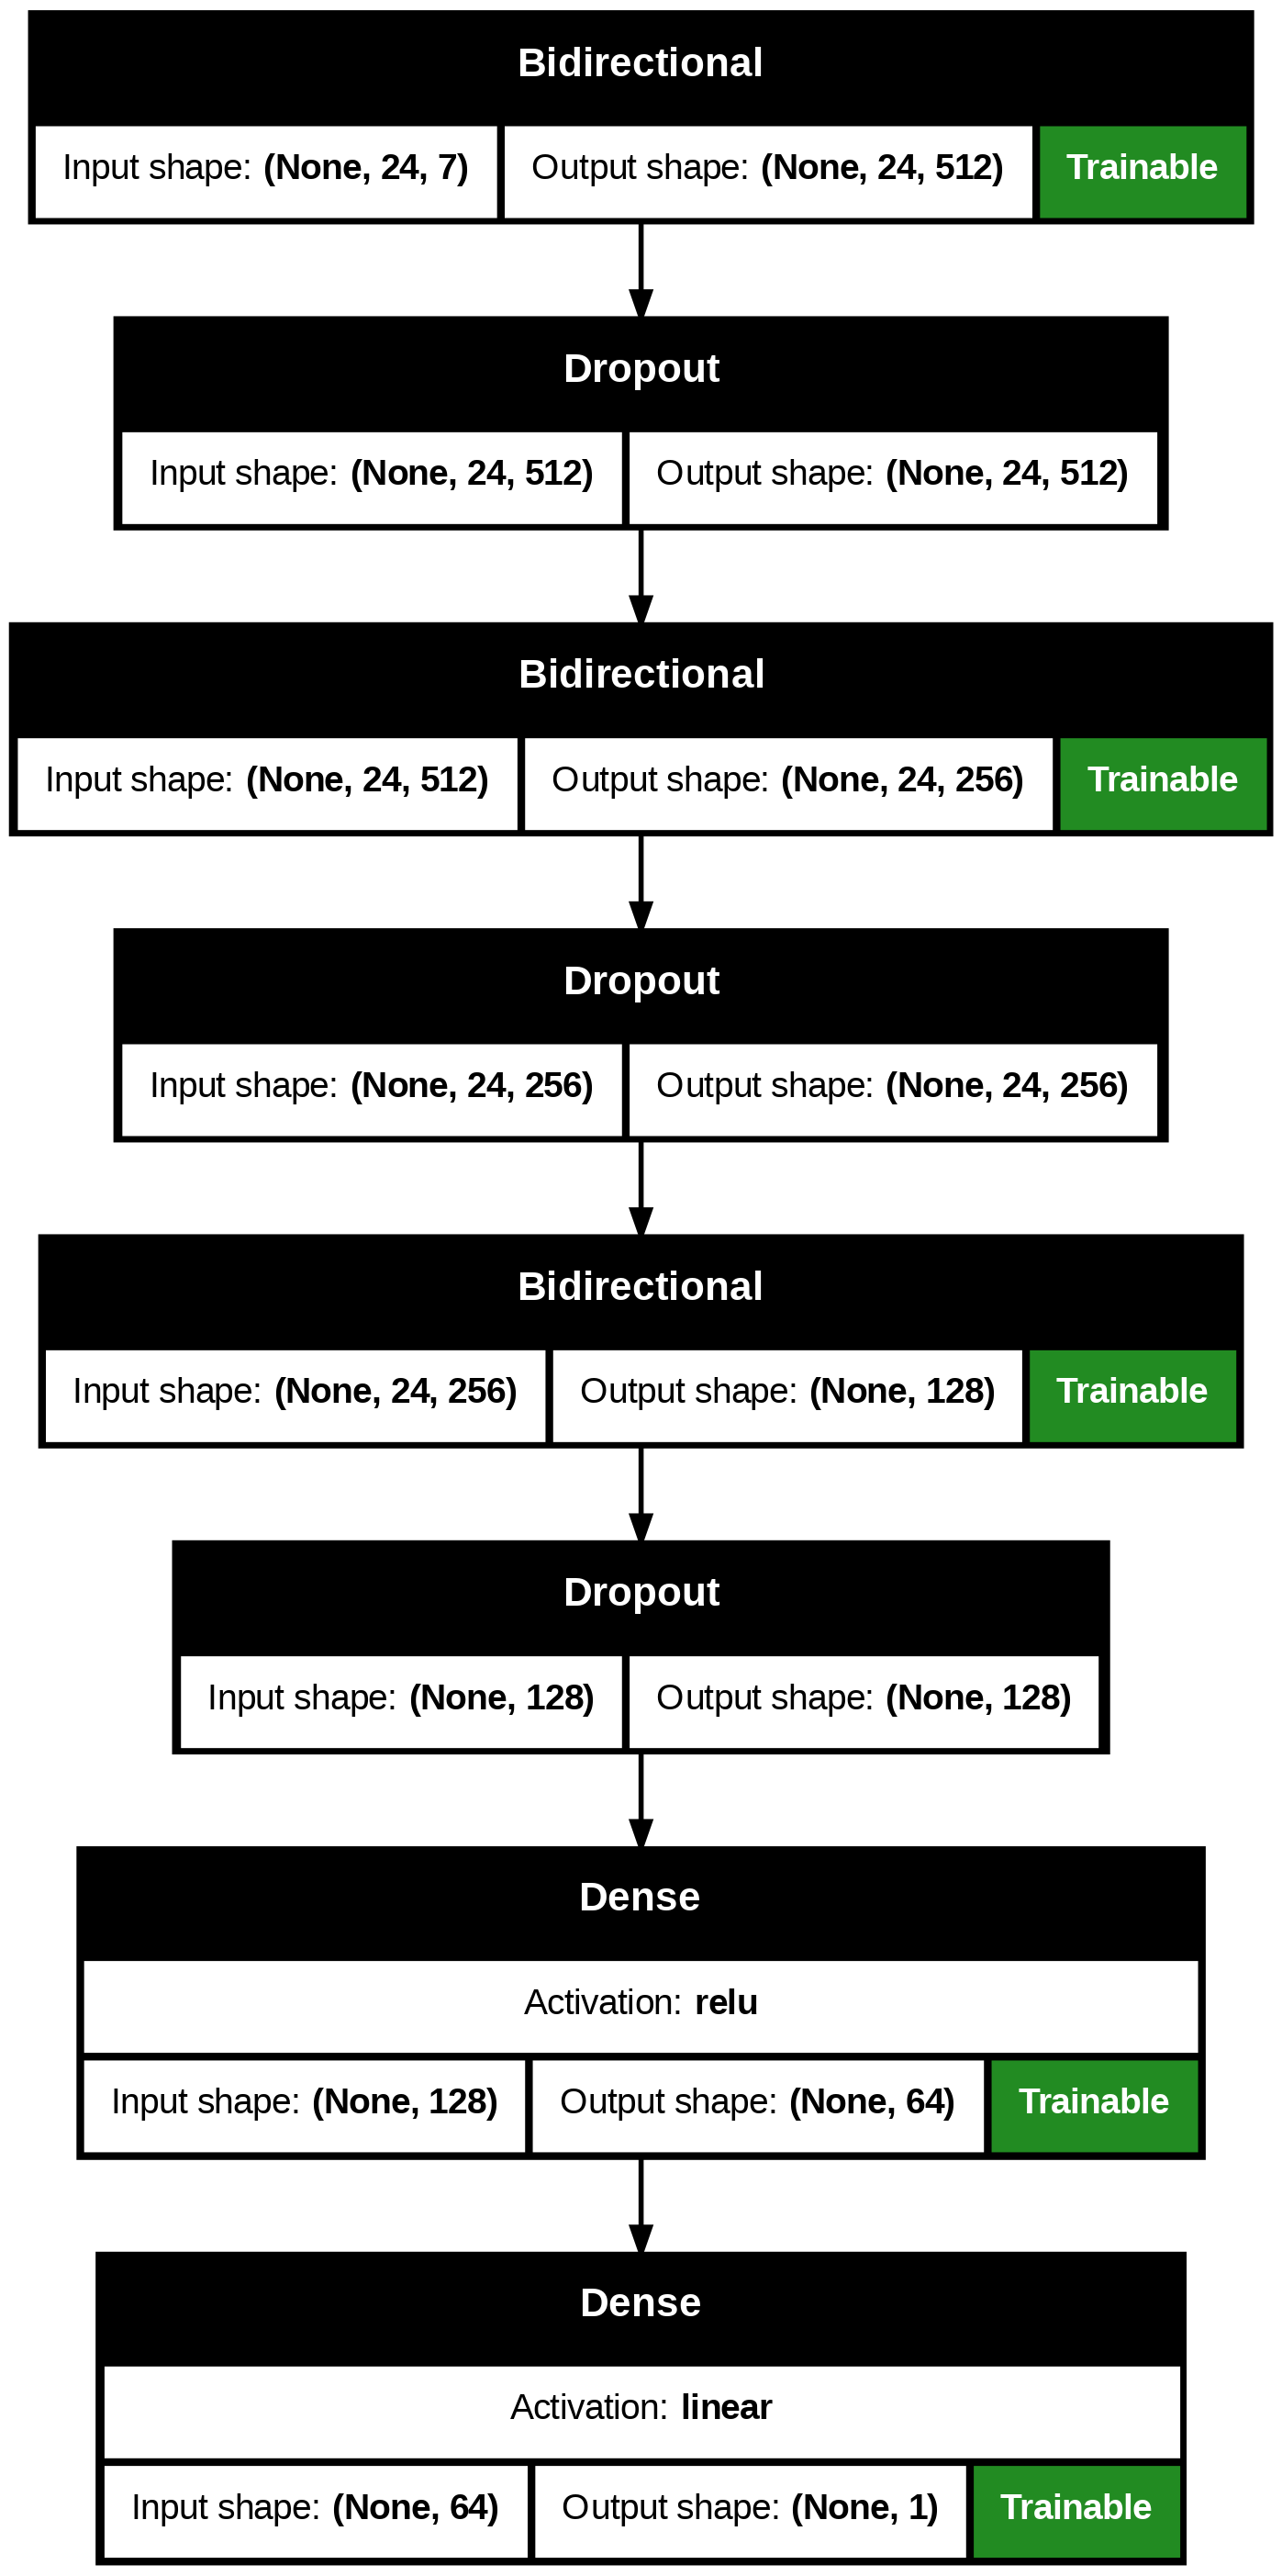

In [29]:
import tensorflow as tf
tf.keras.utils.plot_model(model,dpi=200,show_trainable=True,show_layer_activations=True,show_shapes=True)

In [30]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss='huber',metrics=['mae'])

In [31]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
early_stopper=EarlyStopping(patience=5,restore_best_weights=True,monitor='val_loss')
lr_scheduler=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6)
model_check=ModelCheckpoint('best_model_lstm.h5',save_best_only=True,monitor='val_loss')

In [32]:
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=50,batch_size=64,verbose=1,callbacks=[early_stopper,model_check,lr_scheduler])

Epoch 1/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0039 - mae: 0.0612

616/616 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0031 - mae: 0.0545 - val_loss: 0.0021 - val_mae: 0.0479 - learning_rate: 0.0010
Epoch 2/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0026 - mae: 0.0495

616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0026 - mae: 0.0486 - val_loss: 0.0019 - val_mae: 0.0457 - learning_rate: 0.0010
Epoch 3/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0024 - mae: 0.0475 - val_loss: 0.0021 - val_mae: 0.0439 - learning_rate: 0.0010
Epoch 4/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - mae: 0.0473

616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0024 - mae: 0.0467 - val_loss: 0.0019 - val_mae: 0.0425 - learning_rate: 0.0010
Epoch 5/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0023 - mae: 0.0460 - val_loss: 0.0020 - val_mae: 0.0447 - learning_rate: 0.0010
Epoch 6/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - mae: 0.0449

616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0022 - mae: 0.0443 - val_loss: 0.0019 - val_mae: 0.0427 - learning_rate: 5.0000e-04
Epoch 7/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0022 - mae: 0.0440 - val_loss: 0.0019 - val_mae: 0.0442 - learning_rate: 5.0000e-04
Epoch 8/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - mae: 0.0434

616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0021 - mae: 0.0436 - val_loss: 0.0018 - val_mae: 0.0438 - learning_rate: 5.0000e-04
Epoch 9/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0021 - mae: 0.0431 - val_loss: 0.0018 - val_mae: 0.0416 - learning_rate: 5.0000e-04
Epoch 10/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0020 - mae: 0.0425 - val_loss: 0.0020 - val_mae: 0.0445 - learning_rate: 5.0000e-04
Epoch 11/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020 - mae: 0.0423

616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0020 - mae: 0.0419 - val_loss: 0.0017 - val_mae: 0.0399 - learning_rate: 5.0000e-04
Epoch 12/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0018 - mae: 0.0405

616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0018 - mae: 0.0405 - val_loss: 0.0015 - val_mae: 0.0390 - learning_rate: 2.5000e-04
Epoch 13/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0018 - mae: 0.0402 - val_loss: 0.0018 - val_mae: 0.0402 - learning_rate: 2.5000e-04
Epoch 14/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0018 - mae: 0.0397 - val_loss: 0.0017 - val_mae: 0.0406 - learning_rate: 2.5000e-04
Epoch 15/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0017 - mae: 0.0393 - val_loss: 0.0017 - val_mae: 0.0406 - learning_rate: 2.5000e-04
Epoch 16/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0016 - mae: 0.0382 - val_loss: 0.0018 - val_mae: 0.0415 - learning_rate: 1.2500e-04
Epoch 17/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0016 - mae: 0.0377 - val_loss: 0.0016 - val_mae: 0.0385 - learning_rate: 1.2500e-04


In [33]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,explained_variance_score
y_test_pred=y_scaler.inverse_transform(model.predict(X_test_seq))
y_test_true=y_scaler.inverse_transform(y_test_seq)
test_mae=mean_absolute_error(y_test_true,y_test_pred)
test_mse=mean_squared_error(y_test_true,y_test_pred)
test_rmse=np.sqrt(test_mse)
test_r2=r2_score(y_test_true,y_test_pred)
test_evs=explained_variance_score(y_test_true,y_test_pred)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [34]:
print("\nTest Metrics:")
print(f"MAE: {test_mae:.4f}")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²: {test_r2:.4f}")
print(f"EVS: {test_evs:.4f}")


Test Metrics:
MAE: 39.7637
MSE: 3479.7275
RMSE: 58.9892
R²: 0.6539
EVS: 0.6544


In [35]:
y_val_pred=y_scaler.inverse_transform(model.predict(X_val))
y_val_true=y_scaler.inverse_transform(y_val)
val_mae=mean_absolute_error(y_val_true,y_val_pred)
val_mse=mean_squared_error(y_val_true,y_val_pred)
val_rmse=np.sqrt(val_mse)
val_r2=r2_score(y_val_true,y_val_pred)
val_evs=explained_variance_score(y_val_true,y_val_pred)

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [36]:
print("\nValidation Metrics:")
print(f"MAE: {val_mae:.4f}")
print(f"MSE: {val_mse:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²: {val_r2:.4f}")
print(f"EVS: {val_evs:.4f}")


Validation Metrics:
MAE: 38.7746
MSE: 2975.2373
RMSE: 54.5457
R²: 0.6253
EVS: 0.6598


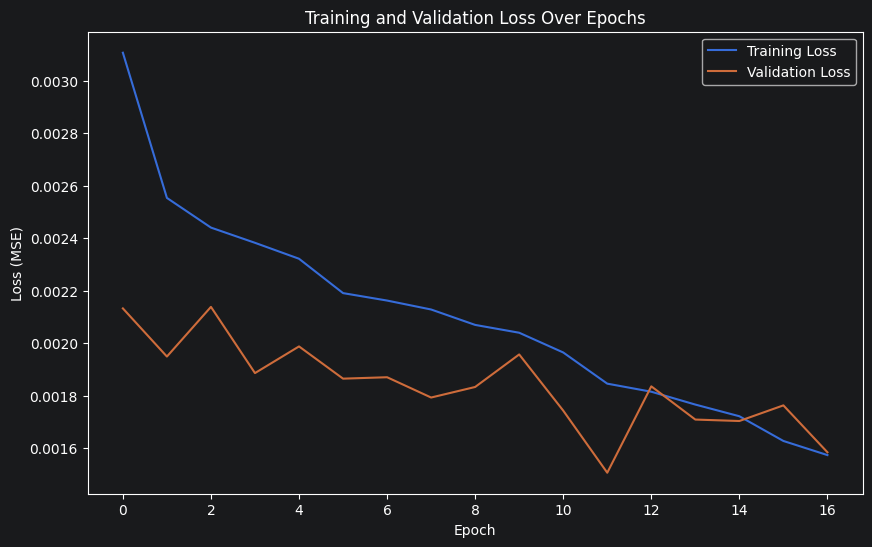

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

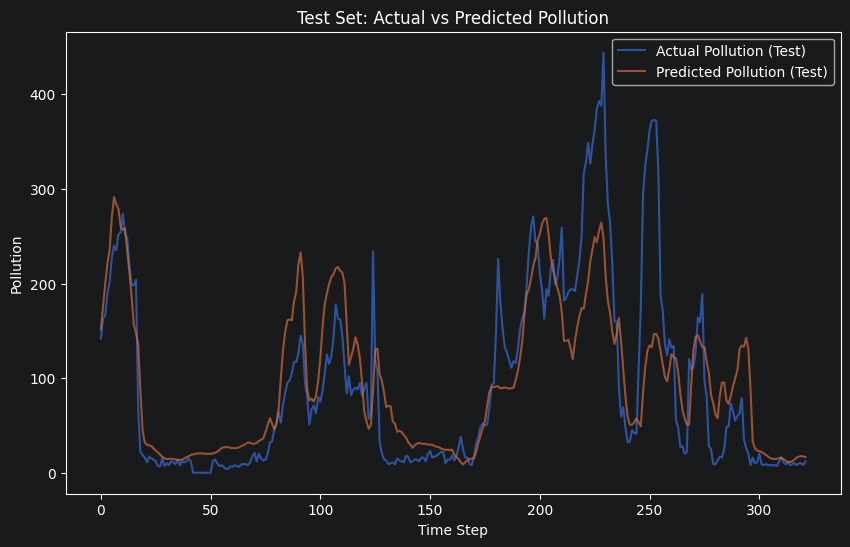

In [38]:
plt.figure(figsize=(10,6))
plt.plot(y_test_true,label='Actual Pollution (Test)',alpha=0.7)
plt.plot(y_test_pred,label='Predicted Pollution (Test)',alpha=0.7)
plt.title('Test Set: Actual vs Predicted Pollution')
plt.xlabel('Time Step')
plt.ylabel('Pollution')
plt.legend()
plt.show()

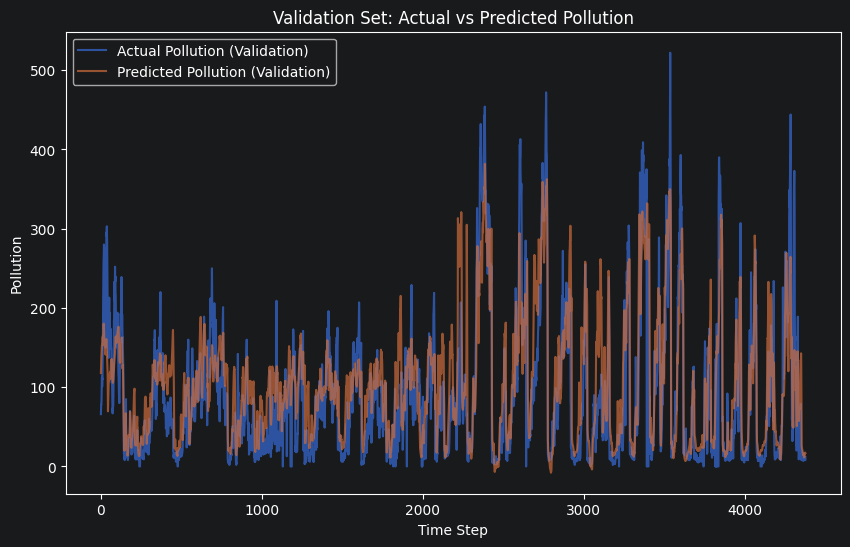

In [39]:
plt.figure(figsize=(10,6))
plt.plot(y_val_true,label='Actual Pollution (Validation)',alpha=0.7)
plt.plot(y_val_pred,label='Predicted Pollution (Validation)',alpha=0.7)
plt.title('Validation Set: Actual vs Predicted Pollution')
plt.xlabel('Time Step')
plt.ylabel('Pollution')
plt.legend()
plt.show()

In [40]:
model.save('model.h5')